### Importação das bibliotecas e carregamento dos dados pré-processados

In [155]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd

# Importando as funções modulares criadas pela equipe
from src.preprocessing import load_processed_data
from src.evaluation import evaluate_model, save_results

# Carregando os conjuntos já pré-processados pelo Notebook 01
X_train_res, X_val, X_test, y_train_res, y_val, y_test, preprocessador = load_processed_data('../data/processed')

print(f"Treino Balanceado (X_train_res): {X_train_res.shape}")
print(f"Validação (X_val): {X_val.shape}")
print(f"Teste Interno (X_test): {X_test.shape}")

Treino Balanceado (X_train_res): (37046, 2052)
Validação (X_val): (6554, 2052)
Teste Interno (X_test): (6554, 2052)


## **Regressão Logística**

### Treinamento do modelo base

In [156]:
from sklearn.linear_model import LogisticRegression

# Modelo com hiperparâmetros padrão, usado como referência antes da tunagem
modelo_base = LogisticRegression(max_iter=1000, random_state=42)
modelo_base.fit(X_train_res, y_train_res)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Avaliação do modelo base no conjunto de validação

In [157]:
metricas_base = evaluate_model(modelo_base, X_val, y_val, model_name='Regressão Logística (base)')

--- Métricas: Regressão Logística (base) ---
accuracy  : 0.8358
precision : 0.9754
recall    : 0.8471
f1        : 0.9067
auc_roc   : 0.8205

Matriz de confusão:
[[ 248  132]
 [ 944 5230]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.2081    0.6526    0.3155       380
           1     0.9754    0.8471    0.9067      6174

    accuracy                         0.8358      6554
   macro avg     0.5917    0.7499    0.6111      6554
weighted avg     0.9309    0.8358    0.8724      6554



### Tunagem de hiperparâmetros

In [158]:
from sklearn.model_selection import GridSearchCV

# Busca em grade pelo parâmetro de regularização C, usando AUC-ROC como
# métrica de seleção por ser adequada à avaliação de problemas desbalanceados
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
}

busca = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
)

busca.fit(X_train_res, y_train_res)

print("Melhores hiperparâmetros:", busca.best_params_)
print(f"Melhor AUC-ROC (CV): {busca.best_score_:.4f}")

modelo_otimizado = busca.best_estimator_


Melhores hiperparâmetros: {'C': 100}
Melhor AUC-ROC (CV): 0.9531


### Avaliação do modelo otimizado no conjunto de validação

In [159]:
metricas_val = evaluate_model(modelo_otimizado, X_val, y_val, model_name='Regressão Logística')


--- Métricas: Regressão Logística ---
accuracy  : 0.8421
precision : 0.9729
recall    : 0.8562
f1        : 0.9108
auc_roc   : 0.7981

Matriz de confusão:
[[ 233  147]
 [ 888 5286]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.2079    0.6132    0.3105       380
           1     0.9729    0.8562    0.9108      6174

    accuracy                         0.8421      6554
   macro avg     0.5904    0.7347    0.6106      6554
weighted avg     0.9286    0.8421    0.8760      6554



### Avaliação final no conjunto de teste interno

In [160]:
metricas_teste = evaluate_model(modelo_otimizado, X_test, y_test, model_name='Regressão Logística')

# Salvando as métricas para a comparação entre modelos na Fase 3
save_results(metricas_teste, output_path='../results/resultados_modelos.csv')


--- Métricas: Regressão Logística ---
accuracy  : 0.8479
precision : 0.9743
recall    : 0.8612
f1        : 0.9143
auc_roc   : 0.8130

Matriz de confusão:
[[ 239  140]
 [ 857 5318]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.2181    0.6306    0.3241       379
           1     0.9743    0.8612    0.9143      6175

    accuracy                         0.8479      6554
   macro avg     0.5962    0.7459    0.6192      6554
weighted avg     0.9306    0.8479    0.8802      6554



,modelo,accuracy,precision,recall,f1,auc_roc
0,Random Forest,0.944309,0.963317,0.978138,0.970671,0.832778
1,XGBoost,0.943699,0.958465,0.982834,0.970497,0.790781
2,Random Forest (Sem SMOTE),0.945987,0.959867,0.983806,0.971689,0.832723
3,Regressão Logística,0.847879,0.974350,0.861215,0.914296,0.812999


### Visualização dos Resultados

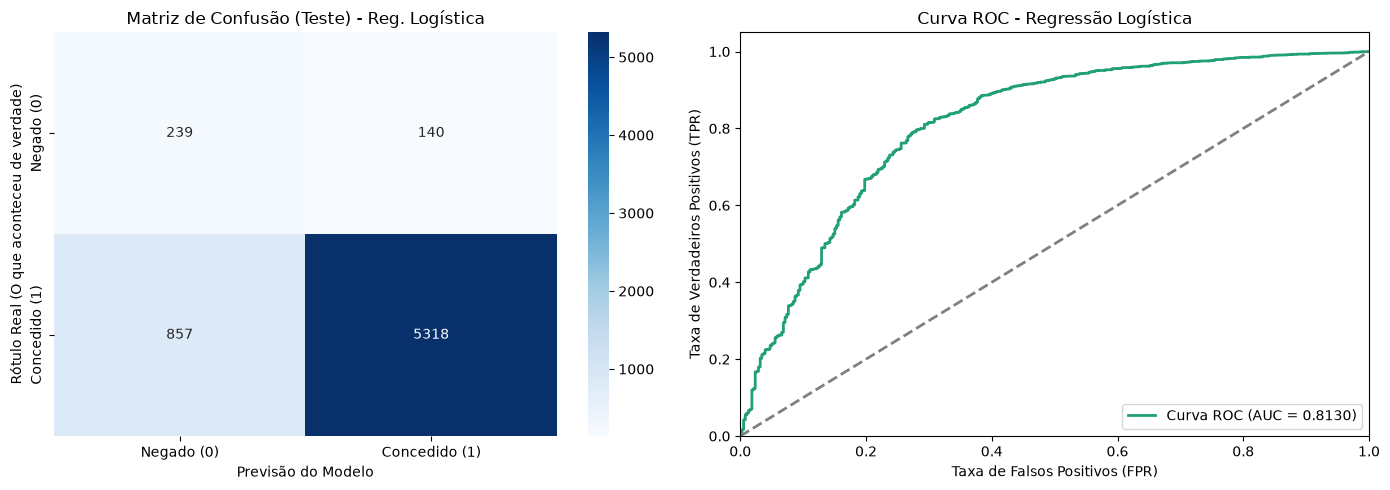

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Criando a área do gráfico (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Gráfico 1: Matriz de Confusão (Heatmap)

y_pred_teste = modelo_otimizado.predict(X_test)
cm = confusion_matrix(y_test, y_pred_teste)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negado (0)', 'Concedido (1)'],
            yticklabels=['Negado (0)', 'Concedido (1)'])
axes[0].set_title('Matriz de Confusão (Teste) - Reg. Logística', fontsize=12)
axes[0].set_ylabel('Rótulo Real (O que aconteceu de verdade)')
axes[0].set_xlabel('Previsão do Modelo')


# Gráfico 2: Curva ROC

y_prob_teste = modelo_otimizado.predict_proba(X_test)[:, 1]

# Calculando a curva
fpr, tpr, thresholds = roc_curve(y_test, y_prob_teste)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#22a075', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title('Curva ROC - Regressão Logística', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Salvando o modelo treinado

In [162]:
import joblib
from pathlib import Path

# Modelo salvo para reuso, sem precisar repetir o treinamento e a tunagem
Path('../models').mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_otimizado, '../models/modelo_regressao_logistica.pkl')

print("Modelo salvo em models/modelo_regressao_logistica.pkl")


Modelo salvo em models/modelo_regressao_logistica.pkl


## **Random Forest**

### Treinamento do modelo base

In [163]:
from sklearn.ensemble import RandomForestClassifier

# Modelo com hiperparâmetros padrão, usado como referência antes da tunagem
modelo_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_base.fit(X_train_res, y_train_res)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### Avaliação do modelo base no conjunto de validação

In [164]:
metricas_base = evaluate_model(modelo_base, X_val, y_val, model_name='Random Forest (base)')


--- Métricas: Random Forest (base) ---
accuracy  : 0.9474
precision : 0.9651
recall    : 0.9796
f1        : 0.9723
auc_roc   : 0.8401

Matriz de confusão:
[[ 161  219]
 [ 126 6048]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5610    0.4237    0.4828       380
           1     0.9651    0.9796    0.9723      6174

    accuracy                         0.9474      6554
   macro avg     0.7630    0.7016    0.7275      6554
weighted avg     0.9416    0.9474    0.9439      6554



### Tunagem de hiperparâmetros

In [165]:
from sklearn.model_selection import RandomizedSearchCV

# Busca aleatória sobre o número de árvores, profundidade máxima e tamanho
# mínimo das folhas, usando AUC-ROC como métrica de seleção
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

busca = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
)

busca.fit(X_train_res, y_train_res)

print("Melhores hiperparâmetros:", busca.best_params_)
print(f"Melhor AUC-ROC (CV): {busca.best_score_:.4f}")

modelo_otimizado = busca.best_estimator_


Melhores hiperparâmetros: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Melhor AUC-ROC (CV): 0.9929


### Avaliação do modelo otimizado no conjunto de validação

In [166]:
metricas_val = evaluate_model(modelo_otimizado, X_val, y_val, model_name='Random Forest')


--- Métricas: Random Forest ---
accuracy  : 0.9461
precision : 0.9644
recall    : 0.9789
f1        : 0.9716
auc_roc   : 0.8391

Matriz de confusão:
[[ 157  223]
 [ 130 6044]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5470    0.4132    0.4708       380
           1     0.9644    0.9789    0.9716      6174

    accuracy                         0.9461      6554
   macro avg     0.7557    0.6961    0.7212      6554
weighted avg     0.9402    0.9461    0.9426      6554



### Importância das variáveis

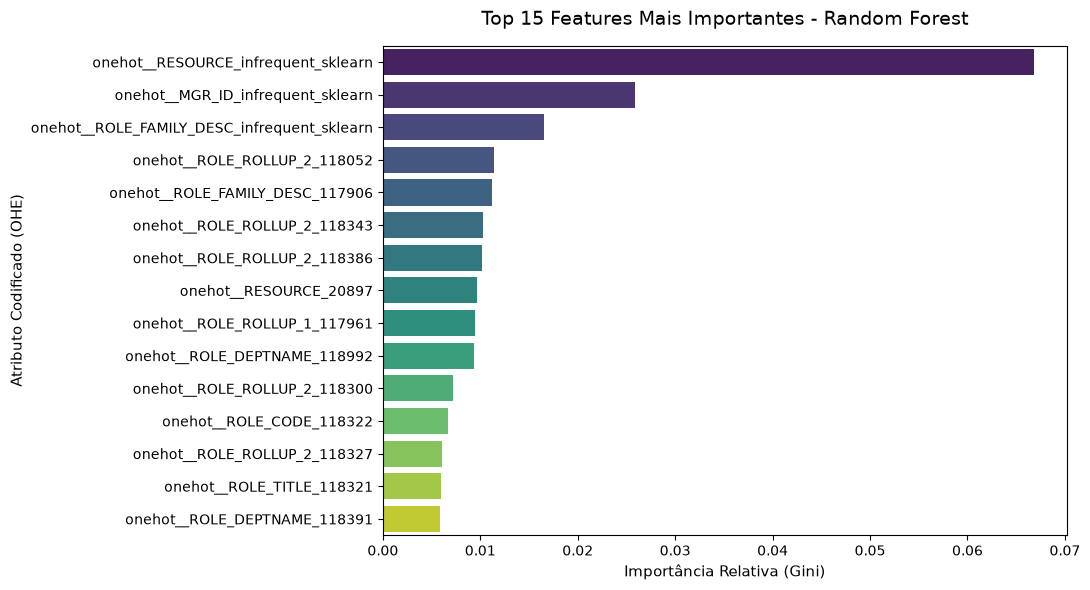

onehot__RESOURCE_infrequent_sklearn            0.066838
onehot__MGR_ID_infrequent_sklearn              0.025839
onehot__ROLE_FAMILY_DESC_infrequent_sklearn    0.016496
onehot__ROLE_ROLLUP_2_118052                   0.011391
onehot__ROLE_FAMILY_DESC_117906                0.011170
onehot__ROLE_ROLLUP_2_118343                   0.010245
onehot__ROLE_ROLLUP_2_118386                   0.010155
onehot__RESOURCE_20897                         0.009666
onehot__ROLE_ROLLUP_1_117961                   0.009475
onehot__ROLE_DEPTNAME_118992                   0.009388
onehot__ROLE_ROLLUP_2_118300                   0.007246
onehot__ROLE_CODE_118322                       0.006694
onehot__ROLE_ROLLUP_2_118327                   0.006084
onehot__ROLE_TITLE_118321                      0.005918
onehot__ROLE_DEPTNAME_118391                   0.005884
onehot__ROLE_ROLLUP_2_118225                   0.005824
onehot__ROLE_CODE_117908                       0.005592
onehot__MGR_ID_54618                           0

In [167]:
# As features mais importantes ajudam a entender quais atributos
# (recurso, gerente, papel) mais influenciam a decisão de acesso

importancias = pd.Series(
    modelo_otimizado.feature_importances_,
    index=preprocessador.get_feature_names_out(),
).sort_values(ascending=False)

importancias_top15 = importancias.head(15).reset_index()
importancias_top15.columns = ['Feature', 'Importância']

plt.figure(figsize=(11, 6))
# Usando a paleta viridis para dar o mesmo acabamento do seu projeto
sns.barplot(x='Importância', y='Feature', data=importancias_top15, palette='viridis', hue='Feature', legend=False)

plt.title('Top 15 Features Mais Importantes - Random Forest', fontsize=14, pad=15)
plt.xlabel('Importância Relativa (Gini)', fontsize=11)
plt.ylabel('Atributo Codificado (OHE)', fontsize=11)
plt.tight_layout()
plt.show()

importancias.head(20)


### Avaliação final no conjunto de teste interno

In [168]:
metricas_teste = evaluate_model(modelo_otimizado, X_test, y_test, model_name='Random Forest')

# Salvando as métricas para a comparação entre modelos na Fase 3
save_results(metricas_teste, output_path='../results/resultados_modelos.csv')


--- Métricas: Random Forest ---
accuracy  : 0.9443
precision : 0.9633
recall    : 0.9781
f1        : 0.9707
auc_roc   : 0.8328

Matriz de confusão:
[[ 149  230]
 [ 135 6040]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5246    0.3931    0.4495       379
           1     0.9633    0.9781    0.9707      6175

    accuracy                         0.9443      6554
   macro avg     0.7440    0.6856    0.7101      6554
weighted avg     0.9380    0.9443    0.9405      6554



,modelo,accuracy,precision,recall,f1,auc_roc
0,XGBoost,0.943699,0.958465,0.982834,0.970497,0.790781
1,Random Forest (Sem SMOTE),0.945987,0.959867,0.983806,0.971689,0.832723
2,Regressão Logística,0.847879,0.974350,0.861215,0.914296,0.812999
3,Random Forest,0.944309,0.963317,0.978138,0.970671,0.832778


### Visualização dos Resultados

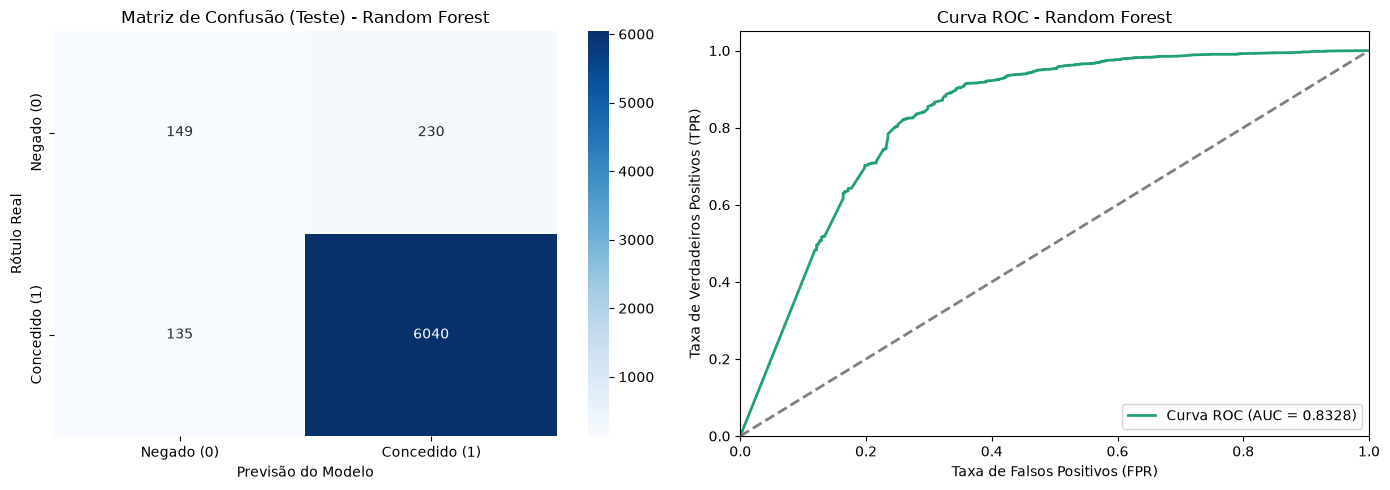

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 1. Matriz de Confusão em Heatmap

y_pred_rf = modelo_otimizado.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negado (0)', 'Concedido (1)'],
            yticklabels=['Negado (0)', 'Concedido (1)'])
axes[0].set_title('Matriz de Confusão (Teste) - Random Forest', fontsize=12)
axes[0].set_ylabel('Rótulo Real')
axes[0].set_xlabel('Previsão do Modelo')


# 2. Curva ROC

y_prob_rf = modelo_otimizado.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, color='#22a075', lw=2, label=f'Curva ROC (AUC = {roc_auc_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title('Curva ROC - Random Forest', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Salvando o modelo treinado

In [170]:
import joblib
from pathlib import Path

# Modelo salvo para reuso, sem precisar repetir o treinamento e a tunagem
Path('../models').mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_otimizado, '../models/modelo_random_forest.pkl')

print("Modelo salvo em models/modelo_random_forest.pkl")


Modelo salvo em models/modelo_random_forest.pkl


## **XGBoost**

### Treinamento do modelo base

In [171]:
from xgboost import XGBClassifier

# Modelo com hiperparâmetros padrão, usado como referência antes da tunagem
modelo_base = XGBClassifier(
    n_estimators=200,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
modelo_base.fit(X_train_res, y_train_res)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Avaliação do modelo base no conjunto de validação

In [172]:
metricas_base = evaluate_model(modelo_base, X_val, y_val, model_name='XGBoost (base)')


--- Métricas: XGBoost (base) ---
accuracy  : 0.9446
precision : 0.9586
recall    : 0.9836
f1        : 0.9710
auc_roc   : 0.8066

Matriz de confusão:
[[ 118  262]
 [ 101 6073]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5388    0.3105    0.3940       380
           1     0.9586    0.9836    0.9710      6174

    accuracy                         0.9446      6554
   macro avg     0.7487    0.6471    0.6825      6554
weighted avg     0.9343    0.9446    0.9375      6554



### Tunagem de hiperparâmetros

In [173]:
from sklearn.model_selection import RandomizedSearchCV

# Busca aleatória sobre a taxa de aprendizado, profundidade máxima, número de
# árvores e amostragem, usando AUC-ROC como métrica de seleção
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

busca = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='roc_auc',
    cv=2,
    random_state=42,
    n_jobs=-1,
)

busca.fit(X_train_res, y_train_res)

print("Melhores hiperparâmetros:", busca.best_params_)
print(f"Melhor AUC-ROC (CV): {busca.best_score_:.4f}")

modelo_otimizado = busca.best_estimator_


Melhores hiperparâmetros: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Melhor AUC-ROC (CV): 0.9844


### Avaliação do modelo otimizado no conjunto de validação

In [174]:
metricas_val = evaluate_model(modelo_otimizado, X_val, y_val, model_name='XGBoost')


--- Métricas: XGBoost ---
accuracy  : 0.9434
precision : 0.9579
recall    : 0.9832
f1        : 0.9703
auc_roc   : 0.8015

Matriz de confusão:
[[ 113  267]
 [ 104 6070]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5207    0.2974    0.3786       380
           1     0.9579    0.9832    0.9703      6174

    accuracy                         0.9434      6554
   macro avg     0.7393    0.6403    0.6745      6554
weighted avg     0.9325    0.9434    0.9360      6554



### Importância das Variáveis

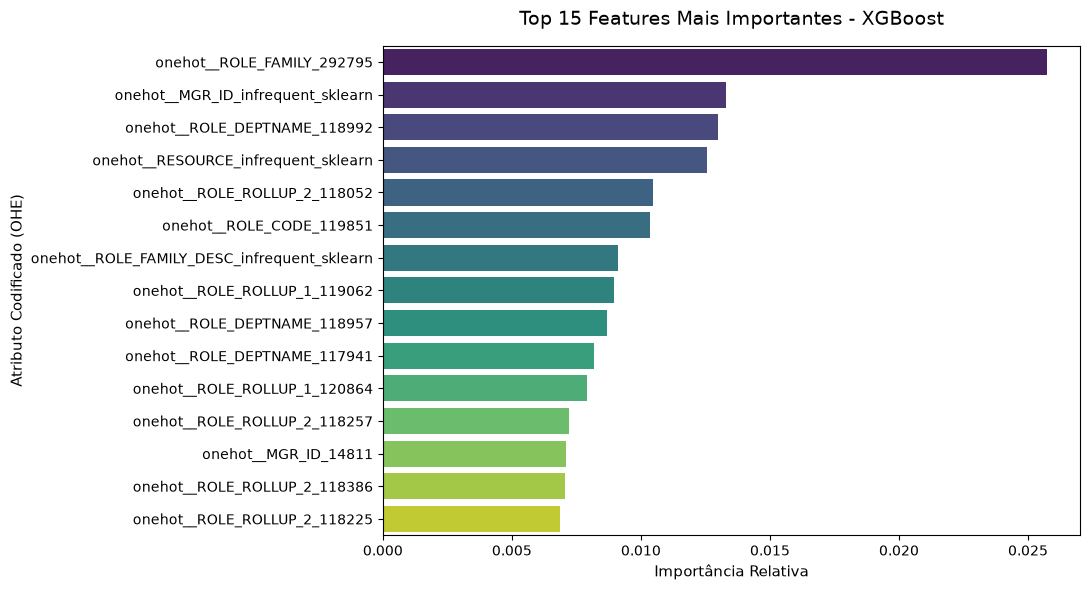

onehot__ROLE_FAMILY_292795                     0.025729
onehot__MGR_ID_infrequent_sklearn              0.013298
onehot__ROLE_DEPTNAME_118992                   0.012994
onehot__RESOURCE_infrequent_sklearn            0.012553
onehot__ROLE_ROLLUP_2_118052                   0.010477
onehot__ROLE_CODE_119851                       0.010370
onehot__ROLE_FAMILY_DESC_infrequent_sklearn    0.009118
onehot__ROLE_ROLLUP_1_119062                   0.008963
onehot__ROLE_DEPTNAME_118957                   0.008675
onehot__ROLE_DEPTNAME_117941                   0.008188
onehot__ROLE_ROLLUP_1_120864                   0.007928
onehot__ROLE_ROLLUP_2_118257                   0.007201
onehot__MGR_ID_14811                           0.007115
onehot__ROLE_ROLLUP_2_118386                   0.007073
onehot__ROLE_ROLLUP_2_118225                   0.006868
onehot__ROLE_FAMILY_19721                      0.006665
onehot__ROLE_ROLLUP_1_91261                    0.006635
onehot__ROLE_DEPTNAME_117912                   0

In [175]:
# Extraindo a importância direto do modelo XGBoost

importancias_xgb = pd.Series(
    modelo_otimizado.feature_importances_,
    index=preprocessador.get_feature_names_out()
).sort_values(ascending=False)

importancias_xgb_top15 = importancias_xgb.head(15).reset_index()
importancias_xgb_top15.columns = ['Feature', 'Importância']

plt.figure(figsize=(11, 6))
sns.barplot(x='Importância', y='Feature', data=importancias_xgb_top15, palette='viridis', hue='Feature', legend=False)

plt.title('Top 15 Features Mais Importantes - XGBoost', fontsize=14, pad=15)
plt.xlabel('Importância Relativa', fontsize=11)
plt.ylabel('Atributo Codificado (OHE)', fontsize=11)
plt.tight_layout()
plt.show()

importancias_xgb.head(20)

### Avaliação final no conjunto de teste interno

In [176]:
metricas_teste = evaluate_model(modelo_otimizado, X_test, y_test, model_name='XGBoost')

# Salvando as métricas para a comparação entre modelos na Fase 3
save_results(metricas_teste, output_path='../results/resultados_modelos.csv')


--- Métricas: XGBoost ---
accuracy  : 0.9437
precision : 0.9585
recall    : 0.9828
f1        : 0.9705
auc_roc   : 0.7908

Matriz de confusão:
[[ 116  263]
 [ 106 6069]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5225    0.3061    0.3860       379
           1     0.9585    0.9828    0.9705      6175

    accuracy                         0.9437      6554
   macro avg     0.7405    0.6445    0.6783      6554
weighted avg     0.9333    0.9437    0.9367      6554



,modelo,accuracy,precision,recall,f1,auc_roc
0,Random Forest (Sem SMOTE),0.945987,0.959867,0.983806,0.971689,0.832723
1,Regressão Logística,0.847879,0.974350,0.861215,0.914296,0.812999
2,Random Forest,0.944309,0.963317,0.978138,0.970671,0.832778
3,XGBoost,0.943699,0.958465,0.982834,0.970497,0.790781


### Visualização dos Resultados

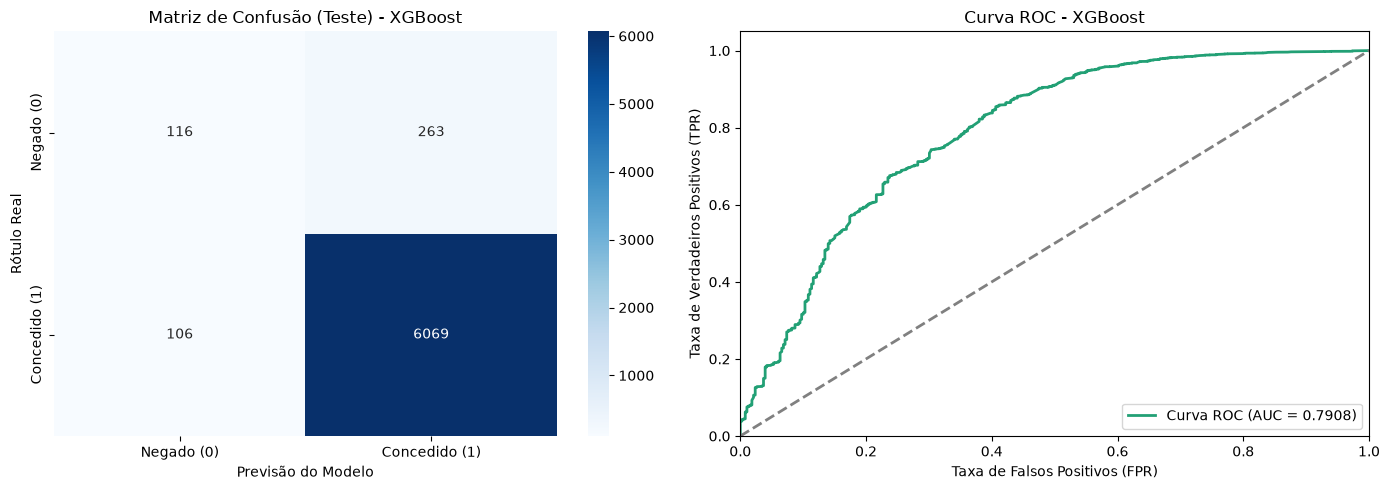

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 1. Matriz de Confusão em Heatmap

y_pred_xgb = modelo_otimizado.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negado (0)', 'Concedido (1)'],
            yticklabels=['Negado (0)', 'Concedido (1)'])
axes[0].set_title('Matriz de Confusão (Teste) - XGBoost', fontsize=12)
axes[0].set_ylabel('Rótulo Real')
axes[0].set_xlabel('Previsão do Modelo')


# 2. Curva ROC

y_prob_xgb = modelo_otimizado.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

axes[1].plot(fpr_xgb, tpr_xgb, color='#22a075', lw=2, label=f'Curva ROC (AUC = {roc_auc_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title('Curva ROC - XGBoost', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Salvando o modelo treinado

In [178]:
import joblib
from pathlib import Path

# Modelo salvo para reuso, sem precisar repetir o treinamento e a tunagem
Path('../models').mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_otimizado, '../models/modelo_xgboost.pkl')

print("Modelo salvo em models/modelo_xgboost.pkl")


Modelo salvo em models/modelo_xgboost.pkl


## Comparação de Modelos

### Avaliação do impacto do SMOTE (Random Forest)

In [179]:
# Modelo de Random Forest SEM SMOTE para controle de qualidade e comparação de impacto do balanceamento

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Resgatando os dados puros originais (antes do balancemento)
df_original = pd.read_csv('../train.csv')
X_orig = df_original.drop(columns=['ACTION'])
y_orig = df_original['ACTION']

# 2. Refazendo a separação exatamente com a mesma semente (42)
X_temp, _, y_temp, _ = train_test_split(X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig)
X_train_puro, _, y_train_puro, _ = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 3. Aplicando o One-Hot Encoder já treinado apenas no treino puro
X_train_puro_encoded = preprocessador.transform(X_train_puro)

# 4. Treinando o modelo SEM SMOTE
print("Treinando Random Forest Baseline (Sem SMOTE)...")
modelo_rf_sem_smote = RandomForestClassifier(
    n_estimators=100, 
    min_samples_leaf=1, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=-1
)
modelo_rf_sem_smote.fit(X_train_puro_encoded, y_train_puro)

# 5. Avaliando nos dados de teste que já estão na memória
metricas_sem_smote = evaluate_model(modelo_rf_sem_smote, X_test, y_test, model_name='Random Forest (Sem SMOTE)')

# 6. Salvando no CSV
save_results(metricas_sem_smote, output_path='../results/resultados_modelos.csv')
print("✅ Métricas do modelo sem SMOTE adicionadas ao painel de comparação!")

Treinando Random Forest Baseline (Sem SMOTE)...
--- Métricas: Random Forest (Sem SMOTE) ---
accuracy  : 0.9460
precision : 0.9599
recall    : 0.9838
f1        : 0.9717
auc_roc   : 0.8327

Matriz de confusão:
[[ 125  254]
 [ 100 6075]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.5556    0.3298    0.4139       379
           1     0.9599    0.9838    0.9717      6175

    accuracy                         0.9460      6554
   macro avg     0.7577    0.6568    0.6928      6554
weighted avg     0.9365    0.9460    0.9394      6554

✅ Métricas do modelo sem SMOTE adicionadas ao painel de comparação!


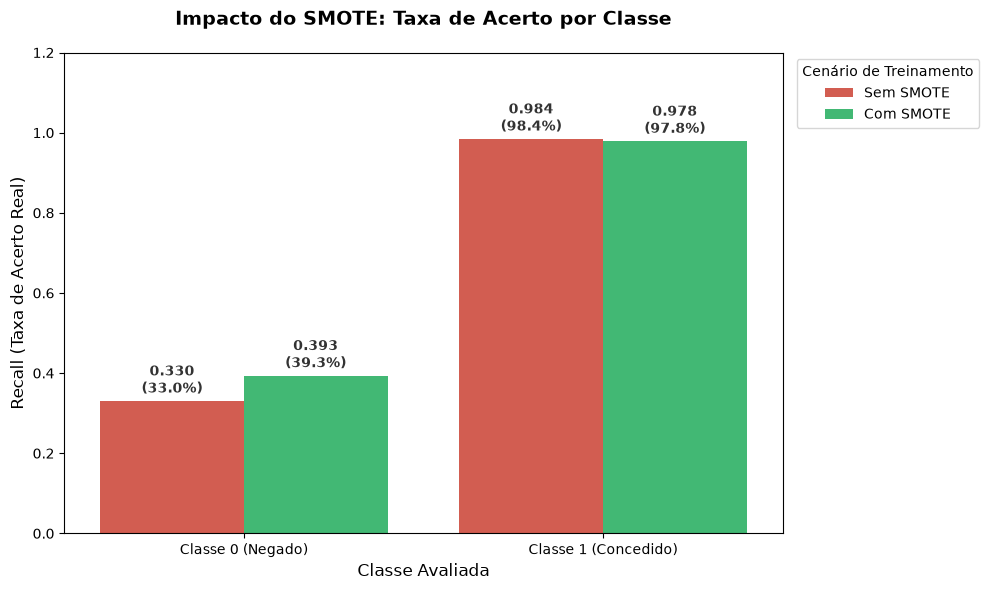

In [182]:
from sklearn.metrics import recall_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Carregando os modelos específicos
modelo_rf_com_smote = joblib.load('../models/modelo_random_forest.pkl')

# 2. Gerando as previsões com os modelos corretos
y_pred_com_smote = modelo_rf_com_smote.predict(X_test)
y_pred_sem_smote = modelo_rf_sem_smote.predict(X_test)

# 3. Extraindo o Recall isolado para a Classe 0 (Negado) e Classe 1 (Concedido)
dados_recall = {
    'Modelo': ['Sem SMOTE', 'Sem SMOTE', 'Com SMOTE', 'Com SMOTE'],
    'Classe': ['Classe 0 (Negado)', 'Classe 1 (Concedido)', 'Classe 0 (Negado)', 'Classe 1 (Concedido)'],
    'Taxa de Acerto (Recall)': [
        recall_score(y_test, y_pred_sem_smote, pos_label=0),
        recall_score(y_test, y_pred_sem_smote, pos_label=1),
        recall_score(y_test, y_pred_com_smote, pos_label=0),
        recall_score(y_test, y_pred_com_smote, pos_label=1)
    ]
}

df_recall_classes = pd.DataFrame(dados_recall)

# 4. Plotando o gráfico focado no problema real
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Classe', 
    y='Taxa de Acerto (Recall)', 
    hue='Modelo', 
    data=df_recall_classes, 
    palette=['#e74c3c', '#2ecc71'] # Vermelho (Sem SMOTE) e Verde (Com SMOTE)
)

# 5. Adicionando os valores em cima das barras com porcentagem
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.3f}\n({altura*100:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    xytext=(0, 15), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#333333')

plt.title('Impacto do SMOTE: Taxa de Acerto por Classe', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Classe Avaliada', fontsize=12)
plt.ylabel('Recall (Taxa de Acerto Real)', fontsize=12)
plt.ylim(0, 1.20) 

plt.legend(title='Cenário de Treinamento', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Comparativo Geral entre modelos

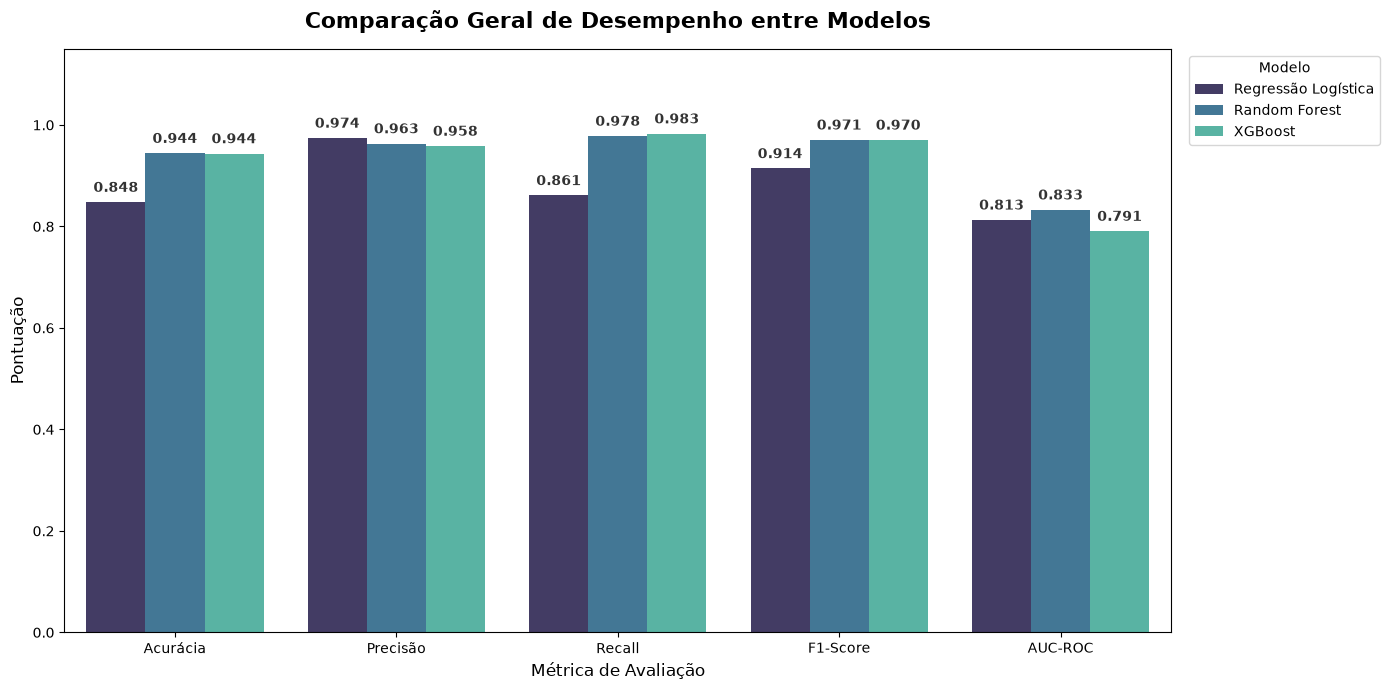

In [181]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregando os resultados
resultados_finais = pd.read_csv('../results/resultados_modelos.csv')

resultados_finais = resultados_finais[resultados_finais['modelo'] != 'Random Forest (Sem SMOTE)']

# 2. Renomeando as colunas para o gráfico ficar em português
resultados_finais = resultados_finais.rename(columns={
    'accuracy': 'Acurácia',
    'precision': 'Precisão',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'auc_roc': 'AUC-ROC'
})

# 3. Transformando as colunas de métricas em linhas
df_grafico = resultados_finais.melt(
    id_vars='modelo', 
    var_name='Métrica', 
    value_name='Pontuação'
)

# 4. Plotando o Gráfico Agrupado
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Métrica', y='Pontuação', hue='modelo', data=df_grafico, palette='mako')

# 5. Adicionando os valores exatos em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.3f}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold',
                    color='#333333')

plt.title('Comparação Geral de Desempenho entre Modelos', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Métrica de Avaliação', fontsize=12)
plt.ylabel('Pontuação', fontsize=12)
plt.ylim(0, 1.15) 
plt.legend(title='Modelo', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()